# Stage 1 (S1) — Train the Teacher: ResNet34 FP32 on CIFAR-10

**Goal (Task 1):** train a full-precision ResNet34 from scratch that generalizes well on CIFAR-10 — strong test accuracy with a small train/test gap — and save the best checkpoint. This becomes the frozen knowledge source for the ternary student (Stage 3).

We evaluate on a held-out validation split for model selection, and only look at the official test set once, at the end, for the reported number.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.utils import set_seed, get_device, plot_training_curves

set_seed(42)
device = get_device()
print("Using device:", device)


Using device: cuda


## Data pipeline
CIFAR-10 downloads to `../data` on first run. Train gets random-crop + horizontal-flip augmentation; val and test do not.

In [2]:
from src.data import get_cifar10_loaders

train_loader, val_loader, test_loader = get_cifar10_loaders(
    data_dir="../data", batch_size=128, val_fraction=0.1, num_workers=2, seed=42
)
print("train batches:", len(train_loader), "| val batches:", len(val_loader),
      "| test batches:", len(test_loader))


100%|███████████████████████████████████████| 170M/170M [35:43<00:00, 79.6kB/s]


train batches: 351 | val batches: 40 | test batches: 79


## Model
CIFAR-adapted ResNet34 (3x3 stride-1 stem, no max-pool — see `src/resnet_cifar.py` for the rationale).

In [3]:
from src.resnet_cifar import resnet34_cifar
from src.utils import count_parameters

teacher = resnet34_cifar(num_classes=10)
print(teacher)
print(f"Total parameters: {count_parameters(teacher):,}")


CifarResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size

## Train
SGD + Nesterov momentum, cosine LR annealing, label smoothing — see `src/config.TeacherConfig` for all hyperparameters in one place. Adjust `epochs` here if you are time-constrained; document whatever you actually used in the report.

In [4]:
from src.config import TeacherConfig
from src.engine import train_supervised

cfg = TeacherConfig()
print(cfg)

history, best_val_acc = train_supervised(
    teacher, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, momentum=cfg.momentum,
    weight_decay=cfg.weight_decay, device=device,
    label_smoothing=cfg.label_smoothing,
    checkpoint_path=cfg.checkpoint_path,
)
print(f"Best validation accuracy: {best_val_acc:.2f}%")


TeacherConfig(epochs=160, batch_size=128, lr=0.1, momentum=0.9, weight_decay=0.0005, label_smoothing=0.1, val_fraction=0.1, seed=42, checkpoint_path='checkpoints/teacher_resnet34_best.pth', curve_plot_path='results/teacher_training_curves.png')
Epoch   1/160 | train_loss 2.4331 acc 12.98% | val_loss 2.0425 acc 23.20% | lr 0.09999
Epoch   2/160 | train_loss 1.8961 acc 31.20% | val_loss 1.7550 acc 39.66% | lr 0.09996
Epoch   3/160 | train_loss 1.6693 acc 44.83% | val_loss 1.5669 acc 50.26% | lr 0.09991
Epoch   4/160 | train_loss 1.4658 acc 55.68% | val_loss 1.4861 acc 55.26% | lr 0.09985
Epoch   5/160 | train_loss 1.2996 acc 63.91% | val_loss 1.2650 acc 65.74% | lr 0.09976
Epoch   6/160 | train_loss 1.2036 acc 68.43% | val_loss 1.1564 acc 70.20% | lr 0.09965
Epoch   7/160 | train_loss 1.1139 acc 72.60% | val_loss 1.1699 acc 70.20% | lr 0.09953
Epoch   8/160 | train_loss 1.0317 acc 76.52% | val_loss 1.0165 acc 77.50% | lr 0.09938
Epoch   9/160 | train_loss 0.9854 acc 78.73% | val_loss 1.0

Epoch  93/160 | train_loss 0.6091 acc 95.30% | val_loss 0.7507 acc 89.34% | lr 0.03738
Epoch  94/160 | train_loss 0.6053 acc 95.60% | val_loss 0.7544 acc 89.24% | lr 0.03643
Epoch  95/160 | train_loss 0.6044 acc 95.54% | val_loss 0.7044 acc 91.40% | lr 0.03549
Epoch  96/160 | train_loss 0.6021 acc 95.64% | val_loss 0.7235 acc 90.84% | lr 0.03455
Epoch  97/160 | train_loss 0.5977 acc 95.85% | val_loss 0.7186 acc 90.98% | lr 0.03362
Epoch  98/160 | train_loss 0.5926 acc 96.08% | val_loss 0.7385 acc 90.18% | lr 0.03269
Epoch  99/160 | train_loss 0.5922 acc 96.11% | val_loss 0.7008 acc 92.00% | lr 0.03178
Epoch 100/160 | train_loss 0.5947 acc 95.91% | val_loss 0.7240 acc 90.28% | lr 0.03087
Epoch 101/160 | train_loss 0.5866 acc 96.35% | val_loss 0.7481 acc 89.60% | lr 0.02996
Epoch 102/160 | train_loss 0.5833 acc 96.46% | val_loss 0.7022 acc 91.28% | lr 0.02907
Epoch 103/160 | train_loss 0.5805 acc 96.57% | val_loss 0.7144 acc 91.10% | lr 0.02818
Epoch 104/160 | train_loss 0.5786 acc 96.72

## Training curves (for the report)

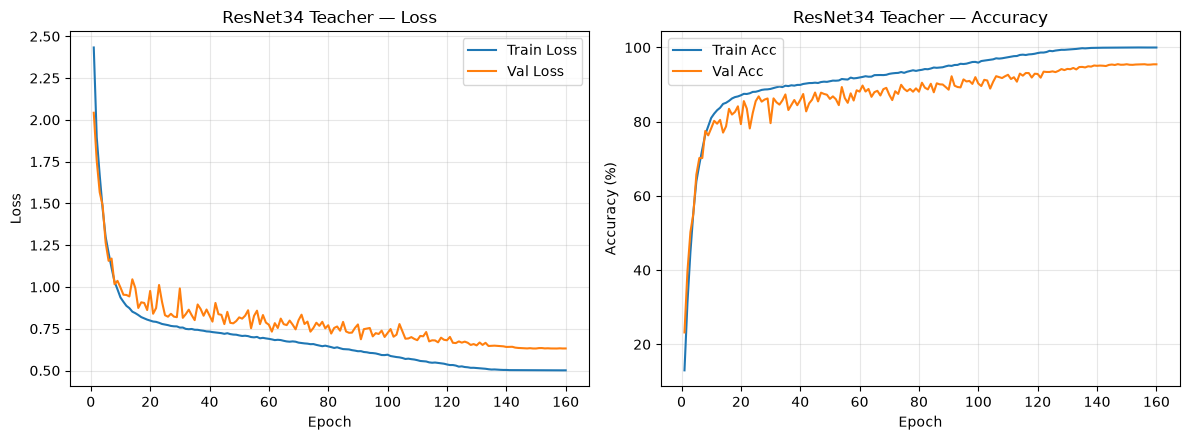

In [5]:
plot_training_curves(history, title="ResNet34 Teacher", save_path=cfg.curve_plot_path)

## Final test-set accuracy and generalization gap
Loaded from the **best** (highest validation accuracy) checkpoint, not the last epoch — avoids reporting an overfit late-training snapshot.

In [6]:
from src.evaluate import evaluate_accuracy
from src.data import get_train_eval_loader

ckpt = torch.load(cfg.checkpoint_path, map_location=device)
teacher.load_state_dict(ckpt["model_state_dict"])
teacher.to(device)

train_eval_loader = get_train_eval_loader(data_dir="../data", batch_size=256)

train_acc = evaluate_accuracy(teacher, train_eval_loader, device)
test_acc = evaluate_accuracy(teacher, test_loader, device)

print(f"Best checkpoint epoch: {ckpt['epoch']}")
print(f"Train accuracy (no augmentation): {train_acc:.2f}%")
print(f"Val accuracy (at best epoch):     {ckpt['val_acc']:.2f}%")
print(f"Test accuracy:                    {test_acc:.2f}%")
print(f"Train-test generalization gap:    {train_acc - test_acc:.2f} pp")

Best checkpoint epoch: 147
Train accuracy (no augmentation): 99.55%
Val accuracy (at best epoch):     95.50%
Test accuracy:                    94.98%
Train-test generalization gap:    4.57 pp


**Interpretation:** a small train/test gap (a few percentage points) indicates good generalization; a large gap suggests overfitting — consider stronger augmentation, more weight decay, or fewer epochs.